### Import Necessary Packages and Libraries

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna

from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay,
    precision_recall_fscore_support, 
    precision_recall_curve,
    fbeta_score, 
    recall_score,
    make_scorer
)

In [2]:
# Read in csv
df = pd.read_csv('~/Desktop/ADA/ADA-final-project/data_ingestion/preprocessed_award_data.csv')
print(df.shape)
df_embed = pd.read_csv('contract_embeddings.csv')

(247241, 36)


In [3]:
df = df.merge(df_embed, on = 'generated_internal_id')
print(df.shape)

(247241, 420)


# Predict Modification within 1 Year (Binary)

In [4]:
# Define columns for Machine Learning Processing
categorical_predictors = ['Awarding Agency' , 'Awarding Sub Agency', 'Funding Agency',
                         'Funding Sub Agency', 'Place of Performance Country Code', 'Place of Performance State Code',
                         'is_democrat', 'naics_code', 'start_year'] # leave out psc_code (~ 900 values)
emb_cols = [col for col in df_embed if col != 'generated_internal_id']
continuous_predictors = ['Award Amount', 'market_share'] + emb_cols
target = 'is_within_year'
metadata = ['internal_id', 'Award ID_x', 'generated_internal_id', 'Recipient Name', 'recipient_id']

In [5]:
df = df[categorical_predictors + continuous_predictors + [target]]
df = df.dropna() # Only drops a few thousand records - insignificant comparatively

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 241966 entries, 2 to 247240
Columns: 396 entries, Awarding Agency to is_within_year
dtypes: float64(389), int64(1), object(6)
memory usage: 732.9+ MB


## Baseline Logistic Regression
### Run K Fold Cross Validation Grid Search

In [7]:
# We use handle_unknown='ignore' for OneHot so the model doesn't crash 
# if the test set has a brand new Agency or NAICS code.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), continuous_predictors),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_predictors)
    ])

# Create the Pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
    ))
])

# Split Data
X = df[categorical_predictors + continuous_predictors]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define Hyperparameters for Grid Search
# 'C' is inverse regularization strength (smaller = more regularization)
# 'penalty' defines L1 (Lasso) vs L2 (Ridge)
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
}

In [35]:
grid_search = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=5, 
    scoring='f1', 
    n_jobs=-1, 
    verbose=3 
    )

print("Starting Grid Search...")
grid_search.fit(X_train, y_train)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")

# Evaluation
y_pred_lr = grid_search.predict(X_test)
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_lr))

Starting Grid Search...
Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV 2/5] END ...................classifier__C=1;, score=0.505 total time= 1.0min
[CV 5/5] END ..................classifier__C=10;, score=0.504 total time=16.2min
[CV 3/5] END .................classifier__C=0.1;, score=0.510 total time= 4.6min
[CV 3/5] END .................classifier__C=100;, score=0.512 total time=12.7min
[CV 2/5] END .................classifier__C=0.1;, score=0.502 total time= 3.7min
[CV 1/5] END .................classifier__C=100;, score=0.505 total time=13.6min
[CV 4/5] END .................classifier__C=0.1;, score=0.505 total time= 5.1min
[CV 4/5] END .................classifier__C=100;, score=0.509 total time=12.4min
[CV 1/5] END .................classifier__C=0.1;, score=0.503 total time= 4.0min
[CV 2/5] END .................classifier__C=100;, score=0.505 total time=13.4min
[CV 5/5] END .................classifier__C=0.1;, score=0.501 total time= 5.1min
[CV 5/5] END ............

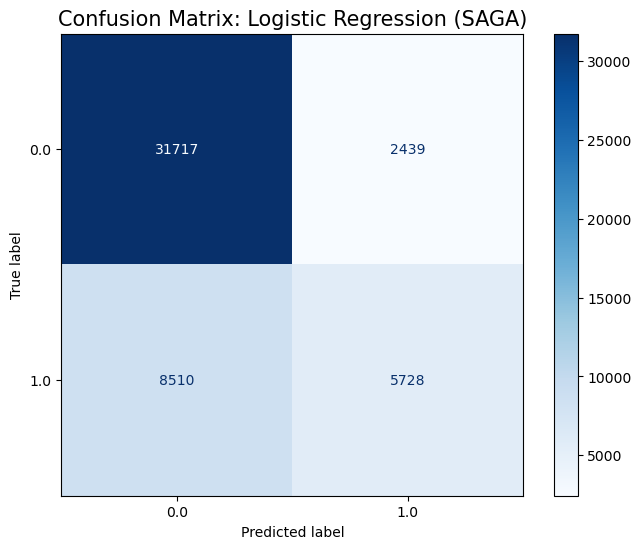

In [36]:
# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=grid_search.classes_)

disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title('Confusion Matrix: Logistic Regression (SAGA)', fontsize=15)
plt.grid(False) # Clean up background lines
plt.show()

## Decision Tree

In [37]:
# Define the Decision Tree Pipeline
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Hyperparameters: focus on depth and leaf constraints to prevent overfitting
dt_param_grid = {
    'classifier__max_depth': [None, 10, 20, 30],
    'classifier__min_samples_split': [2, 10, 20],
    'classifier__criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(dt_pipeline, dt_param_grid, cv=5, scoring='f1', n_jobs=-1, verbose = 3)
dt_grid.fit(X_train, y_train)

print(f"Decision Tree Best Params: {dt_grid.best_params_}")

# Evaluation
y_pred_dt = dt_grid.predict(X_test)
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_dt))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV 4/5] END ...................classifier__C=1;, score=0.509 total time=15.5min
[CV 4/5] END classifier__criterion=gini, classifier__max_depth=None, classifier__min_samples_split=2;, score=0.507 total time= 3.8min


/opt/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV 1/5] END classifier__criterion=gini, classifier__max_depth=None, classifier__min_samples_split=20;, score=0.504 total time= 4.1min
[CV 3/5] END classifier__criterion=gini, classifier__max_depth=10, classifier__min_samples_split=20;, score=0.522 total time= 1.4min
[CV 4/5] END classifier__criterion=gini, classifier__max_depth=20, classifier__min_samples_split=10;, score=0.514 total time= 2.2min
[CV 4/5] END classifier__criterion=gini, classifier__max_depth=30, classifier__min_samples_split=2;, score=0.514 total time= 3.1min
[CV 3/5] END ...................classifier__C=1;, score=0.512 total time=16.1min
[CV 1/5] END classifier__criterion=gini, classifier__max_depth=None, classifier__min_samples_split=10;, score=0.503 total time= 4.1min
[CV 2/5] END classifier__criterion=gini, classifier__max_depth=10, classifier__min_samples_split=20;, score=0.522 total time= 1.4min
[CV 1/5] END classifier__criterion=gini, classifier__max_depth=20, classifier__min_samples_split=20;, score=0.514 tota

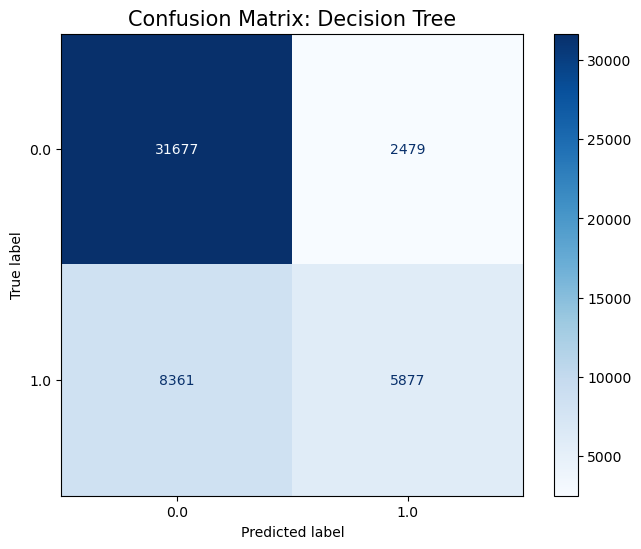

In [38]:
# Generate the confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=grid_search.classes_)

disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title('Confusion Matrix: Decision Tree', fontsize=15)
plt.grid(False) # Clean up background lines
plt.show()

## Random Forest

In [39]:
# Define the Random Forest Pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Hyperparameters: 'n_estimators' is the number of trees
rf_param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 20, None],
    'classifier__max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(rf_pipeline, rf_param_grid, cv=5, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train, y_train)

print(f"Random Forest Best Params: {rf_grid.best_params_}")

# Evaluation
y_pred_rf = rf_grid.predict(X_test)
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_rf))

[CV 2/5] END classifier__criterion=entropy, classifier__max_depth=None, classifier__min_samples_split=10;, score=0.507 total time= 2.9min
[CV 5/5] END classifier__criterion=entropy, classifier__max_depth=10, classifier__min_samples_split=2;, score=0.522 total time= 2.0min
[CV 2/5] END classifier__criterion=entropy, classifier__max_depth=20, classifier__min_samples_split=2;, score=0.511 total time=19.6min
[CV 5/5] END classifier__criterion=entropy, classifier__max_depth=20, classifier__min_samples_split=20;, score=0.516 total time= 3.6min
[CV 4/5] END classifier__criterion=entropy, classifier__max_depth=30, classifier__min_samples_split=20;, score=0.511 total time= 2.0min
[CV 5/5] END classifier__criterion=entropy, classifier__max_depth=None, classifier__min_samples_split=2;, score=0.499 total time= 3.0min
[CV 1/5] END classifier__criterion=entropy, classifier__max_depth=10, classifier__min_samples_split=10;, score=0.511 total time= 2.0min
[CV 5/5] END classifier__criterion=entropy, cla

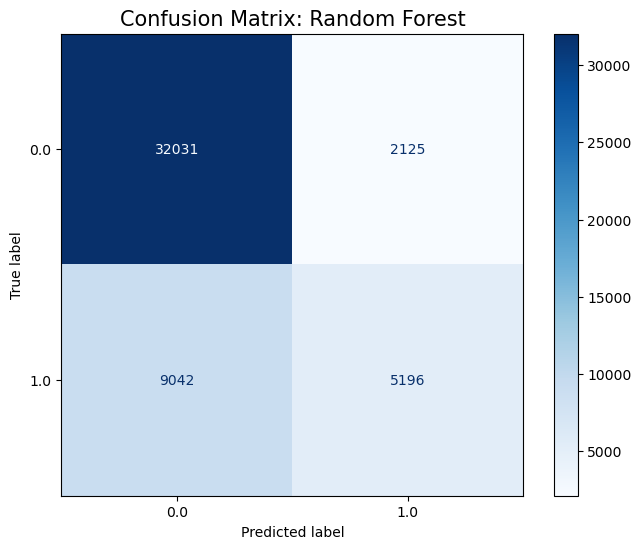

In [40]:
# Generate the confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=grid_search.classes_)

disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title('Confusion Matrix: Random Forest', fontsize=15)
plt.grid(False) # Clean up background lines
plt.show()

## XGBoost

In [ ]:
# Define the XGBoost Pipeline
# XGBoost handles its own weights, but likes the same preprocessed data
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
])

# Hyperparameters: 'learning_rate' (eta) and 'n_estimators' are key
xgb_param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__max_depth': [3, 6, 9]
}

xgb_grid = GridSearchCV(xgb_pipeline, xgb_param_grid, cv=5, scoring='f1', n_jobs=-1)
xgb_grid.fit(X_train, y_train)

print(f"XGBoost Best Params: {xgb_grid.best_params_}")

# Evaluation
y_pred_xgb = xgb_grid.predict(X_test)
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_xgb))

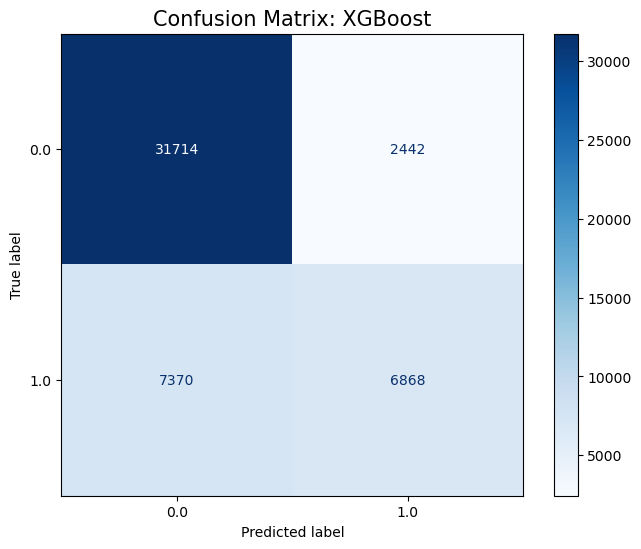

In [42]:
# Generate the confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=grid_search.classes_)

disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title('Confusion Matrix: XGBoost', fontsize=15)
plt.grid(False) # Clean up background lines
plt.show()

### XGBoost Performed the best F1 score with Embeddings
- Next step: Optimzied Recall since makes more sense from a business context
- Use Bayesian Search to find better hyperparameters
- Save to V2 of Model

In [10]:
def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, 10),
        'eval_metric': 'logloss',
        'random_state': 42
    }

    # Create a fresh pipeline for each trial to prevent leakage
    current_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor), # Your imported preprocessor
        ('classifier', XGBClassifier(**param))
    ])
    
    # Cross-validate the ENTIRE pipeline
    score = cross_val_score(current_pipeline, X_train, y_train, cv=5, scoring='recall').mean()
    
    return score

# 4. Run the optimization
study_XGB = optuna.create_study(direction='maximize')
study_XGB.optimize(objective, n_trials=50) # Increase n_trials for better results

print(f"Best Recall Score: {study_XGB.best_value}")
print(f"Best Params: {study_XGB.best_params}")

[I 2026-05-18 11:00:26,749] A new study created in memory with name: no-name-c6a9e6bf-da4d-4c11-80ae-cb74516dfa91
[I 2026-05-18 11:03:15,912] Trial 0 finished with value: 0.8408683231765558 and parameters: {'n_estimators': 569, 'learning_rate': 0.14926722159907774, 'max_depth': 6, 'scale_pos_weight': 9.337973185577555}. Best is trial 0 with value: 0.8408683231765558.
[I 2026-05-18 11:09:22,560] Trial 1 finished with value: 0.5392588568124165 and parameters: {'n_estimators': 855, 'learning_rate': 0.17992511983947207, 'max_depth': 9, 'scale_pos_weight': 1.8890748318444157}. Best is trial 0 with value: 0.8408683231765558.
[I 2026-05-18 11:13:47,936] Trial 2 finished with value: 0.5567167580646861 and parameters: {'n_estimators': 343, 'learning_rate': 0.018281405631172396, 'max_depth': 11, 'scale_pos_weight': 1.7468144388864677}. Best is trial 0 with value: 0.8408683231765558.
[I 2026-05-18 11:15:42,383] Trial 3 finished with value: 0.9393950155058255 and parameters: {'n_estimators': 484, 

Best Recall Score: 0.9983573231183774
Best Params: {'n_estimators': 101, 'learning_rate': 0.013377833484615667, 'max_depth': 4, 'scale_pos_weight': 7.7432624038742475}


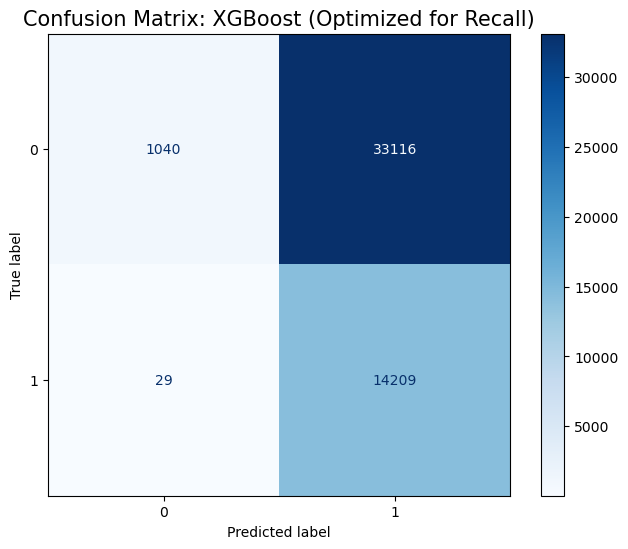

In [11]:
# 1. Remove the deprecated param and refit the final model
best_params = study_XGB.best_params

# 2. Re-build the final pipeline using the best params
# Note: We prepend 'classifier__' so it knows which part of the pipeline to update
final_xgb_model = XGBClassifier(**best_params, eval_metric='logloss', random_state=42)

final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', final_xgb_model)
])

# 3. Fit on the entire training set
final_pipeline.fit(X_train, y_train)

# 4. Predict on the test set
y_pred_xgb = final_pipeline.predict(X_test)

# --- Your Plotting Code ---

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

fig, ax = plt.subplots(figsize=(8, 6))
# Ensure display_labels matches your actual class names (e.g., ['No', 'Yes'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=final_pipeline.classes_)

disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title('Confusion Matrix: XGBoost (Optimized for Recall)', fontsize=15)
plt.grid(False)
plt.show()

### Optimizing for Recall gave amazing recall metrics, severe expense of precision
- Use F-Beta Score Strategy (tells model recall is twice as important as precision, but precision is still important)!

In [15]:
def objective_balancing(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, 5), # Reduced range to prevent over-aggression
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'eval_metric': 'logloss',
        'random_state': 42
    }

    current_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(**param))
    ])
    
    # We create a custom scorer for F2 (Recall-heavy)
    f2_scorer = make_scorer(fbeta_score, beta=2)
    
    score = cross_val_score(current_pipeline, X_train, y_train, cv=5, scoring=f2_scorer).mean()
    
    return score

In [16]:
# 4. Run the optimization
study_XGB_balance = optuna.create_study(direction='maximize')
study_XGB_balance.optimize(objective_balancing, n_trials=50) # Increase n_trials for better results

print(f"Best Recall Score: {study_XGB_balance.best_value}")
print(f"Best Params: {study_XGB_balance.best_params}")

[I 2026-05-18 13:21:50,296] A new study created in memory with name: no-name-f317d56b-17c3-4e7c-ab9f-ce4be717de5d
[I 2026-05-18 13:25:57,398] Trial 0 finished with value: 0.6781984583255543 and parameters: {'n_estimators': 609, 'learning_rate': 0.06421152751061994, 'max_depth': 8, 'scale_pos_weight': 4.7060741074300285, 'subsample': 0.6866417779416715, 'colsample_bytree': 0.878489279331439}. Best is trial 0 with value: 0.6781984583255543.
[I 2026-05-18 13:27:46,072] Trial 1 finished with value: 0.5802263254081446 and parameters: {'n_estimators': 258, 'learning_rate': 0.04855832392134924, 'max_depth': 8, 'scale_pos_weight': 1.6526596321889575, 'subsample': 0.8335485955432625, 'colsample_bytree': 0.6739135046154092}. Best is trial 0 with value: 0.6781984583255543.
[I 2026-05-18 13:33:32,850] Trial 2 finished with value: 0.5552338600704316 and parameters: {'n_estimators': 841, 'learning_rate': 0.1293413073584447, 'max_depth': 8, 'scale_pos_weight': 1.5849268059869428, 'subsample': 0.66985

Best Recall Score: 0.7195432373817328
Best Params: {'n_estimators': 646, 'learning_rate': 0.04093941884963318, 'max_depth': 4, 'scale_pos_weight': 4.9916030092688235, 'subsample': 0.8453513859435784, 'colsample_bytree': 0.8828303538346344}


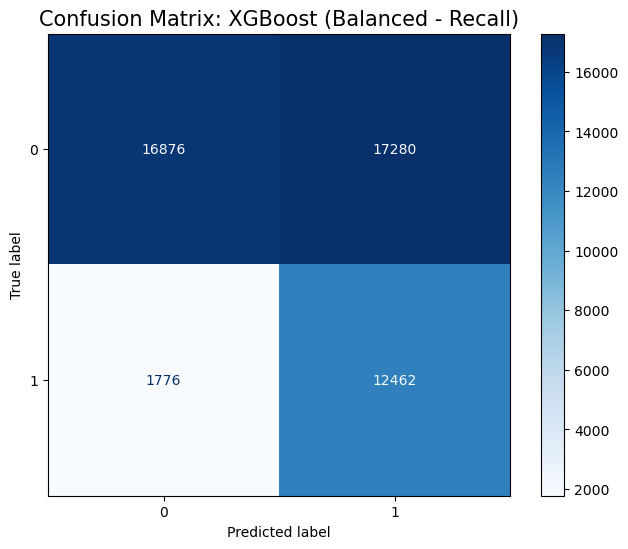

In [22]:
# 1. Remove the deprecated param and refit the final model
best_params_bal = study_XGB_balance.best_params

# 2. Re-build the final pipeline using the best params
# Note: We prepend 'classifier__' so it knows which part of the pipeline to update
final_xgb_model_bal = XGBClassifier(**best_params_bal, eval_metric='logloss', random_state=42)

final_pipeline_bal = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', final_xgb_model_bal)
])

# 3. Fit on the entire training set
final_pipeline_bal.fit(X_train, y_train)

# 4. Predict on the test set
y_pred_xgb_bal = final_pipeline_bal.predict(X_test)

cm_xgb = confusion_matrix(y_test, y_pred_xgb_bal)

fig, ax = plt.subplots(figsize=(8, 6))
# Ensure display_labels matches your actual class names (e.g., ['No', 'Yes'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=final_pipeline_bal.classes_)

disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title('Confusion Matrix: XGBoost (Balanced - Recall)', fontsize=15)
plt.grid(False)
plt.show()

Best Threshold=0.7312, Best F1-Score=0.5757


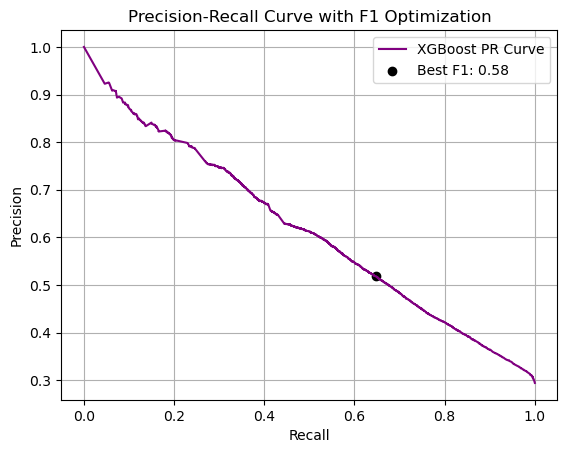

In [21]:
# 1. Get probability scores
y_scores = final_pipeline.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# 2. Calculate F1 score for each threshold
# Note: Using np.errstate to ignore division by zero at the start/end of the arrays
with np.errstate(divide='ignore', invalid='ignore'):
    f1_scores = 2 * (precision * recall) / (precision + recall)
    f1_scores = np.nan_to_num(f1_scores) # Convert NaNs to 0

# 3. Find the optimal threshold that maximizes F1
ix = np.argmax(f1_scores)
best_threshold = thresholds[ix]
best_f1 = f1_scores[ix]

print(f'Best Threshold={best_threshold:.4f}, Best F1-Score={best_f1:.4f}')

# 4. Plotting
plt.plot(recall, precision, color='purple', label='XGBoost PR Curve')
# Scatter point for the best F1 score
plt.scatter(recall[ix], precision[ix], marker='o', color='black', label=f'Best F1: {best_f1:.2f}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve with F1 Optimization')
plt.legend()
plt.grid(True)
plt.show()

Top 20 Most Important Features:


,Feature,Importance
0,naics_code_541512.0,0.093008
1,Funding Agency_Department of Transportation,0.018289
2,Awarding Sub Agency_Department of State,0.017925
3,Award Amount,0.017460
4,Awarding Agency_Department of State,0.014559
5,naics_code_541511.0,0.013444
6,Awarding Agency_Department of Justice,0.012743
7,v_212,0.011435
8,v_166,0.010972
9,v_373,0.010229


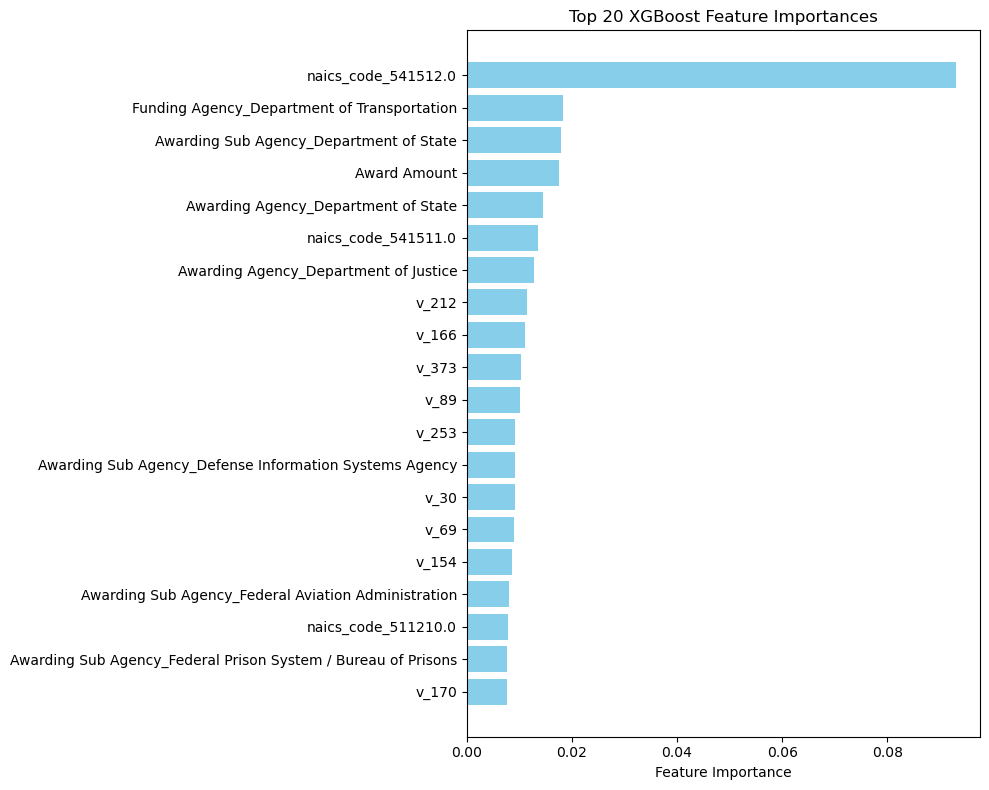

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Get the feature names from the fitted preprocessor
feature_names = preprocessor.get_feature_names_out()

# Clean up the names to remove the 'num__' and 'cat__' prefixes if desired
feature_names_clean = [name.split('__')[-1] for name in feature_names]

# Access the underlying XGBoost model from the last step of the pipeline
importances = final_pipeline_bal.steps[-1][1].feature_importances_

# Create a DataFrame to view and sort them
feature_importance_df = pd.DataFrame({
    'Feature': feature_names_clean,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

# 3. Display the top 20 features
print("Top 20 Most Important Features:")
display(feature_importance_df.head(20))

# Plot the top 20 features for visualization
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['Feature'].head(20)[::-1], 
         feature_importance_df['Importance'].head(20)[::-1], 
         color='skyblue')
plt.xlabel('Feature Importance')
plt.title('Top 20 XGBoost Feature Importances')
plt.tight_layout()
plt.savefig('xgb_feature_importance_mod_binary.png')

# Save Models and Metrics to Disk

In [19]:
version = "v2"

# IMPORTANT!!!!
## Ensure Proper Version Number above is specified before running!

In [20]:
# Dictionary to map your trained grid objects to filenames
model_dict = {
    "Logistic Regression": grid_search,
    "Decision Tree": dt_grid,
    "Random Forest": rf_grid,
    "XGBoost": xgb_grid
    "XGBoost_recall": final_pipeline
    "XGBoost_balanced": final_pipeline_bal
}

results_list = []

for name, model_obj in model_dict.items():
    # 1. Determine the actual estimator/pipeline to save
    # If it's a GridSearch, take the best_estimator_. If it's a Pipeline, take it as-is.
    final_model = getattr(model_obj, "best_estimator_", model_obj)
    
    # 2. Save the model
    filename = f"models/{name.lower().replace(' ', '_')}_model_embed_{version}.joblib"
    joblib.dump(final_model, filename)
    
    # 3. Predict and Calculate Metrics
    y_pred = final_model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    
    # Extract the positive class (assuming it's '1.0' or 1)
    # Using .get() or checking keys helps if labels are ints or strings
    pos_label = '1.0' if '1.0' in report else '1'
    
    results_list.append({
        "model_name": f"{name}_embed_{version}",
        "model_location": filename,
        "precision": report[pos_label]['precision'],
        "recall": report[pos_label]['recall'],
        "f1_score": report[pos_label]['f1-score'],
        "weighted_avg_f1": report['weighted avg']['f1-score'],
        "macro_avg_f1": report['macro avg']['f1-score']
    })

# Convert new results to a DataFrame
df_new_metrics = pd.DataFrame(results_list)

try:
    # Load existing metrics
    df_metrics_old = pd.read_csv("modification_model_evaluation_metrics.csv")
    # Combine and drop duplicates based on the model name
    df_metrics = pd.concat([df_metrics_old, df_new_metrics], axis=0).drop_duplicates(subset=['model_name'], keep='last')
except FileNotFoundError:
    # If the file doesn't exist yet, just use the new metrics
    df_metrics = df_new_metrics

# Final Save
df_metrics.to_csv("modification_model_evaluation_metrics.csv", index=False)
print("Models saved and metrics CSV updated successfully.")

Models saved and metrics CSV updated successfully.
